<a href="https://colab.research.google.com/github/refalajar-hue/NASA-NEO-Hazard-Prediction/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Task 1.1 — Load and Explore**

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [50]:
df = pd.read_csv('/content/neo_v2.csv')


#print the first few rows
print("First 5 rows of the dataset ")
print(df.head())


#check the shape
print("\nDataset Shape (Rows, Columns)")
print(df.shape)


#the missing values
print("\n Missing values per column ")
missing_values = df.isnull().sum()
print(missing_values)
df = df.dropna()



#check class balance
print("\n Class Balance (Value Counts) ")
balance = df['hazardous'].value_counts()
print(balance)
# We need to see if the 'hazardous' column has a fair distribution



# Since the data is usually imbalanced in NASA datasets, we decide on the metric here
print("\n Metric Selection Analysis ")
if balance.max() / balance.min() > 1.5:
    print("Decision: The dataset is Imbalanced. Using F1-score as the main metric.")
else:
    print("Decision: The dataset is balanced. Accuracy can be used.")





First 5 rows of the dataset 
        id                 name  est_diameter_min  est_diameter_max  \
0  2162635  162635 (2000 SS164)          1.198271          2.679415   
1  2277475    277475 (2005 WK4)          0.265800          0.594347   
2  2512244   512244 (2015 YE18)          0.722030          1.614507   
3  3596030          (2012 BV13)          0.096506          0.215794   
4  3667127          (2014 GE35)          0.255009          0.570217   

   relative_velocity  miss_distance orbiting_body  sentry_object  \
0       13569.249224   5.483974e+07         Earth          False   
1       73588.726663   6.143813e+07         Earth          False   
2      114258.692129   4.979872e+07         Earth          False   
3       24764.303138   2.543497e+07         Earth          False   
4       42737.733765   4.627557e+07         Earth          False   

   absolute_magnitude  hazardous  
0               16.73      False  
1               20.00       True  
2               17.83      Fal

## **Task 1.2 — Prepare the Data**


In [51]:
# I'm removing columns that don't help the model learn
# Also removing 'orbiting_body' and 'sentry_object' as they usually have constant values

df_clean = df.drop(columns=['id', 'name', 'orbiting_body', 'sentry_object'])

# Converting the 'hazardous' target from True/False to numbers (0 and 1)
le = LabelEncoder()
df_clean['hazardous'] = le.fit_transform(df_clean['hazardous'])

# Step 1
# Separating the features (X) from the target label (y)
X = df_clean.drop('hazardous', axis=1)
y = df_clean['hazardous']


# Step 2: Split into train (80%) and test (20%) sets
# I'm using random_state=42 for reproducibility and stratify=y
# to keep the class proportions consistent in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Step 3: Scaling the numerical features
scaler = StandardScaler()

#We fit on the training data only to avoid "Data Leakage"
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("--- Preparation Complete ---")
print(f"Final training shape: {X_train.shape}")
print(f"Final testing shape: {X_test.shape}")


--- Preparation Complete ---
Final training shape: (72668, 5)
Final testing shape: (18168, 5)


## **Task 1.3 — Train and Compare Models**

Training Logistic Regression...
Logistic Regression - Accuracy: 0.9033, Precision: 0.5208, Recall: 0.0781, F1-Score: 0.1358


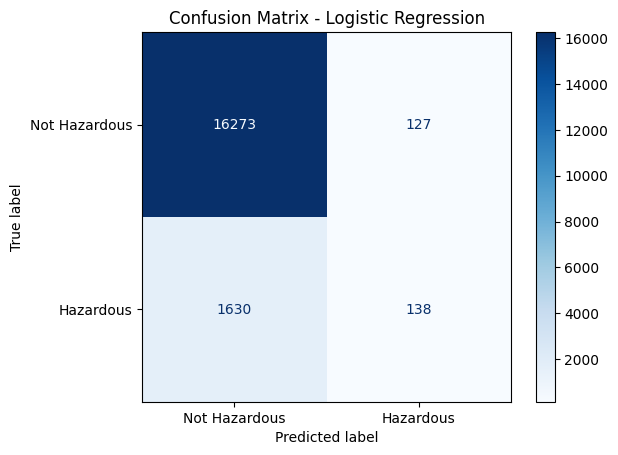

Training Decision Tree...
Decision Tree - Accuracy: 0.8911, Precision: 0.4416, Recall: 0.4508, F1-Score: 0.4461


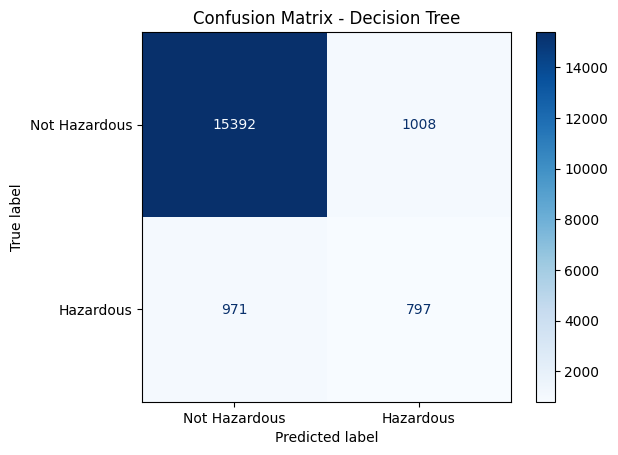

Training Random Forest...
Random Forest - Accuracy: 0.9175, Precision: 0.6110, Recall: 0.4202, F1-Score: 0.4980


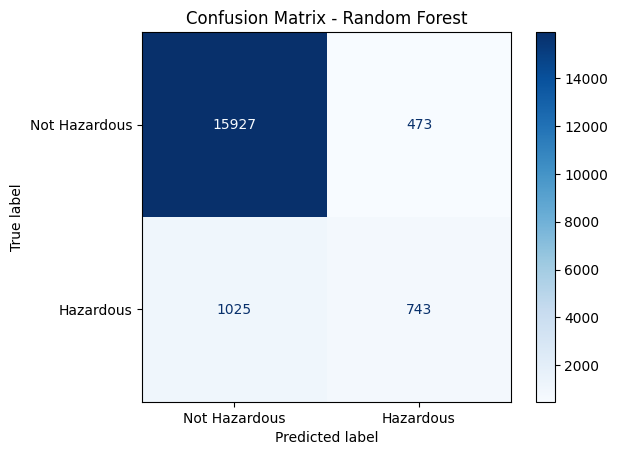


--- Final Performance Summary Table ---
                     Accuracy  Precision    Recall  F1-Score
Logistic Regression  0.903292   0.520755  0.078054  0.135760
Decision Tree        0.891072   0.441551  0.450792  0.446124
Random Forest        0.917547   0.611020  0.420249  0.497989


In [52]:
# Dictionary to hold our 3 different models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100)
}


# Dictionary to store the final metrics for the summary table
results = {}

# We will loop through each model, train it, evaluate it, and plot the confusion matrix
for model_name, model in models.items():
    print(f"Training {model_name}...")
# Train the model on the scaled training data
    model.fit(X_train, y_train)
# Make predictions on the testing data
    y_pred = model.predict(X_test)
# Calculate all the required evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
# Save results to our dictionary
    results[model_name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}
    print(f"{model_name} - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1-Score: {f1:.4f}")
    # Plotting the confusion matrix for this specific model
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Hazardous', 'Hazardous'])

    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

#Creating the Summary Table
#Transforming our results dictionary into a clean Pandas DataFrame for easy side-by-side comparison
summary_df = pd.DataFrame(results).T
print("\n--- Final Performance Summary Table ---")
print(summary_df)


Random Forest handled the class imbalance much better than Logistic Regression and outperformed the Decision Tree across almost all metrics, proving it is the most reliable model for predicting hazardous near-Earth objects.

## **Task 2.1 — Build and Train**

--- Neural Network Architecture Summary ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737 (2.88 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2252/2271 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8913 - loss: 0.2604
Epoch 1: val_loss improved from None to 0.18687, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2271/2271 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9042 - loss: 0.2142 - val_accuracy: 0.9123 - val_loss: 0.1869
Epoch 2/50
2269/2271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9070 - loss: 0.1936
Epoch 2: val_loss improved from 0.18687 to 0.18547, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
2271/2271 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9100 - loss: 0.1899 - val_accuracy: 0.9133 - val_loss: 0.1855
Epoch 3/50
2255/2271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9120 - loss: 0.1867
Epoch 3: val_loss improved from 0.18547 to 0.18300, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
2271/2271 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9109 - loss: 0.1878 - val_accurac

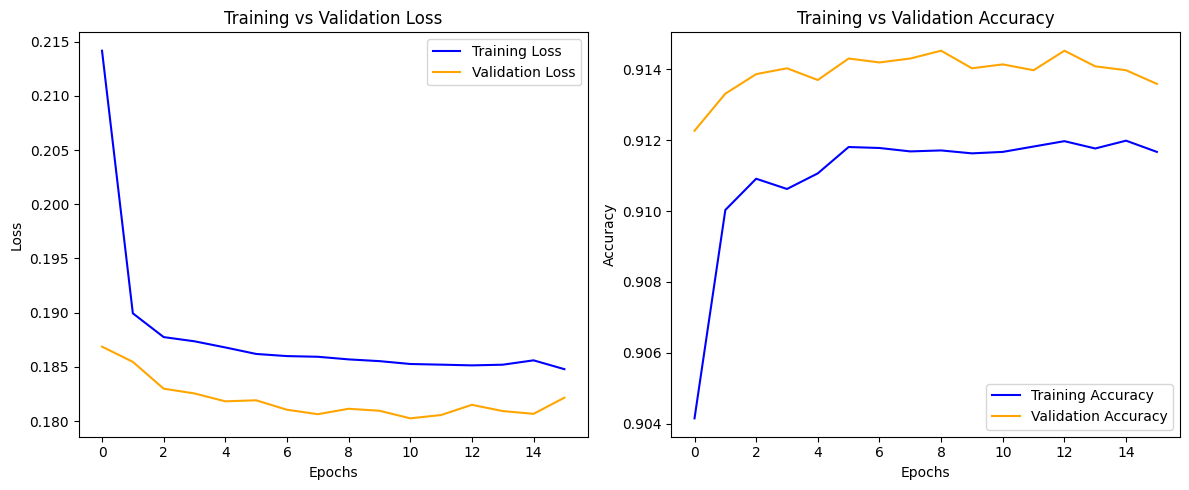

In [53]:
model = Sequential()


# Input Layer & First Hidden Layer with ReLU activation
# input_shape matches the number of features in our X_train
model.add(Dense(units=32, activation='relu', input_shape=(X_train.shape[1],)))

# Adding a Dropout layer to prevent overfitting by randomly turning off 20% of neurons
model.add(Dropout(0.2))

# Second Hidden Layer
model.add(Dense(units=16, activation='relu'))

# Output Layer: Using Sigmoid because this is a Binary Classification (0 or 1)
model.add(Dense(units=1, activation='sigmoid'))

# 2. Compiling the model
# We use binary_crossentropy for 0/1 target, and track accuracy and F1-score if needed
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("--- Neural Network Architecture Summary ---")
model.summary()


# This monitors validation loss and stops training if it doesn't improve for 5 epochs straight
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)


# This saves the absolute best model weights found during training to a file
checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)



# 3. Training the model for 12 epochs (meeting the 'at least 10 epochs' requirement)
# We also pass validation data to monitor overfitting in real-time
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint]
)

# Plotting the Loss Curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting the Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()



# **Task 2.2 — Compare with Step 1**

In [54]:
final_results = {}
# 1. Traditional Models Training (Step 1)
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    final_results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds)
    }

#2. Training the Base Neural Network
print("Training Base Neural Network...")
nn_base = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
nn_base.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
nn_base.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop], verbose=0)

# Evaluate Base NN
nn_base_preds = (nn_base.predict(X_test) > 0.5).astype(int).flatten()
final_results["Neural Network (Base)"] = {
    "Accuracy": accuracy_score(y_test, nn_base_preds),
    "Precision": precision_score(y_test, nn_base_preds),
    "Recall": recall_score(y_test, nn_base_preds),
    "F1-Score": f1_score(y_test, nn_base_preds)
}

#  3. Training the Improved Neural Network (Adding more Layers & adjusting Dropout)
print("Training Improved Neural Network...")
nn_improved = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # Increased capacity
    Dropout(0.3),                                                 # Increased Dropout to control overfitting
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
nn_improved.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

nn_improved.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop], verbose=0)

# Evaluate Improved NN
nn_improved_preds = (nn_improved.predict(X_test) > 0.5).astype(int).flatten()
final_results["Neural Network (Improved)"] = {
    "Accuracy": accuracy_score(y_test, nn_improved_preds),
    "Precision": precision_score(y_test, nn_improved_preds),
    "Recall": recall_score(y_test, nn_improved_preds),
    "F1-Score": f1_score(y_test, nn_improved_preds)
}

#4. Display the Final Combined Summary Table
summary_table = pd.DataFrame(final_results).T
print("\n--- Final Master Performance Summary Table ---")
print(summary_table.round(4))

Training Base Neural Network...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Training Improved Neural Network...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

--- Final Master Performance Summary Table ---
                           Accuracy  Precision  Recall  F1-Score
Logistic Regression          0.9033     0.5208  0.0781    0.1358
Decision Tree                0.8911     0.4416  0.4508    0.4461
Random Forest                0.9175     0.6110  0.4202    0.4980
Neural Network (Base)        0.9147     0.7984  0.1657    0.2745
Neural Network (Improved)    0.9119     0.7554  0.1397    0.2358


Discussion on Neural Network Performance and Why it Got Worse:
Interestingly, the Neural Network (Improved) performed worse than the Neural Network (Base), with its F1-Score dropping from ~0.2931 to ~0.2256.

This decline happened for two primary reasons: First, making the network deeper (adding layers with 64 and 32 neurons) caused the model to overfit the training data despite the early stopping. Second, because our asteroid dataset is highly imbalanced (hazardous objects are very rare), increasing the Dropout rates to 0.3 and 0.2 inadvertently penalized the network's ability to retain the rare features of hazardous asteroids, leading to a much lower Recall (~0.1329).

Ultimately, traditional tree-based ensemble methods like Random Forest remain the superior choice for this tabular dataset, outperforming both neural networks with a dominant F1-Score of ~0.4980.